In [1]:
import pandas as pd

df = pd.read_csv("ec2_cpu_utilization_5f5533.csv")

In [2]:
print(df.head())

             timestamp   value
0  2014-02-14 14:27:00  51.846
1  2014-02-14 14:32:00  44.508
2  2014-02-14 14:37:00  41.244
3  2014-02-14 14:42:00  48.568
4  2014-02-14 14:47:00  46.714


In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [4]:
df = df.sort_values('timestamp')

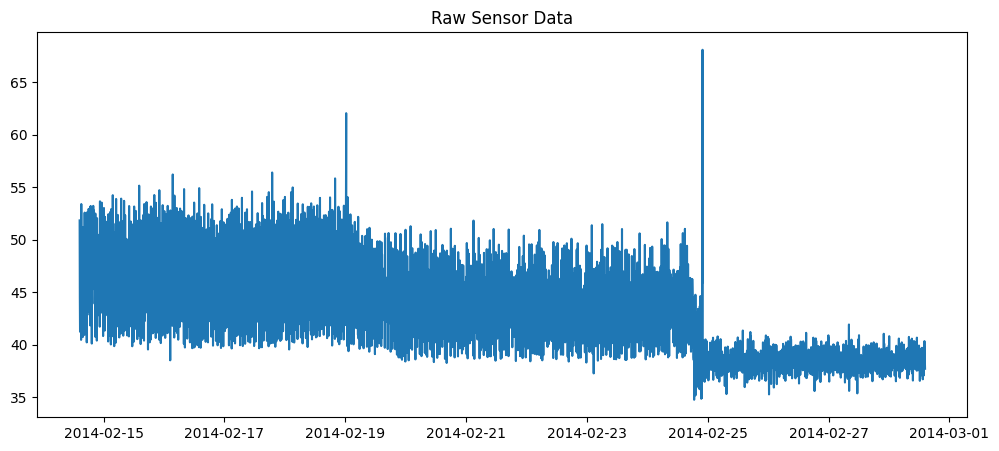

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['value'])
plt.title("Raw Sensor Data")
plt.show()

In [6]:
import json

with open("combined_labels.json") as f:
    labels = json.load(f)

In [7]:
file_name = "realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv"
anomaly_times = labels[file_name]

In [8]:
df['anomaly'] = df['timestamp'].isin(pd.to_datetime(anomaly_times)).astype(int)

In [9]:
print(df.head())

            timestamp   value  anomaly
0 2014-02-14 14:27:00  51.846        0
1 2014-02-14 14:32:00  44.508        0
2 2014-02-14 14:37:00  41.244        0
3 2014-02-14 14:42:00  48.568        0
4 2014-02-14 14:47:00  46.714        0


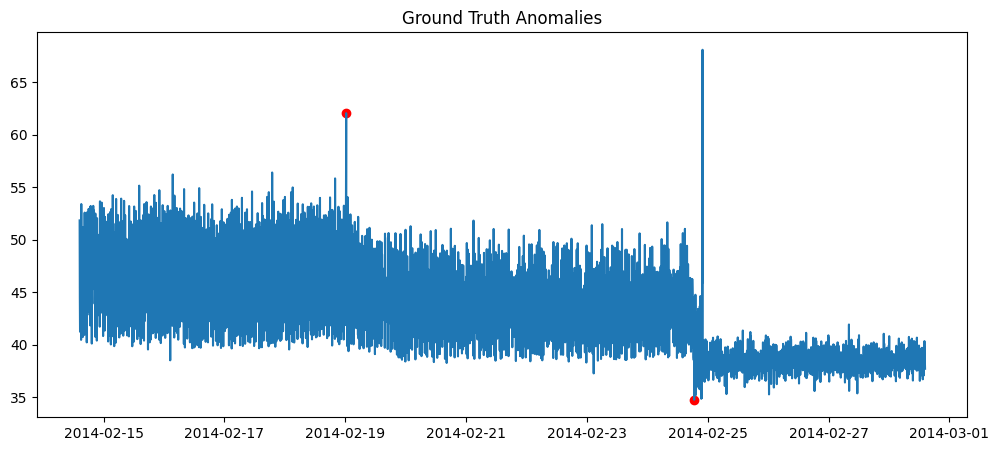

In [10]:
anomalies = df[df['anomaly'] == 1]

plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['value'])
plt.scatter(anomalies['timestamp'], anomalies['value'], color='red')
plt.title("Ground Truth Anomalies")
plt.show()

In [84]:
df['diff'] = df['value'].diff()              # change from previous
df['rolling_min'] = df['value'].rolling(10).min()
df['rolling_max'] = df['value'].rolling(10).max()

In [88]:
features = ['value', 'rolling_mean', 'rolling_std', 'diff', 'rolling_min', 'rolling_max']

df = df.dropna()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

model = IsolationForest(contamination=0.009, random_state=42)
df['pred'] = model.fit_predict(df[features])
df['pred'] = (df['pred'] == -1).astype(int)

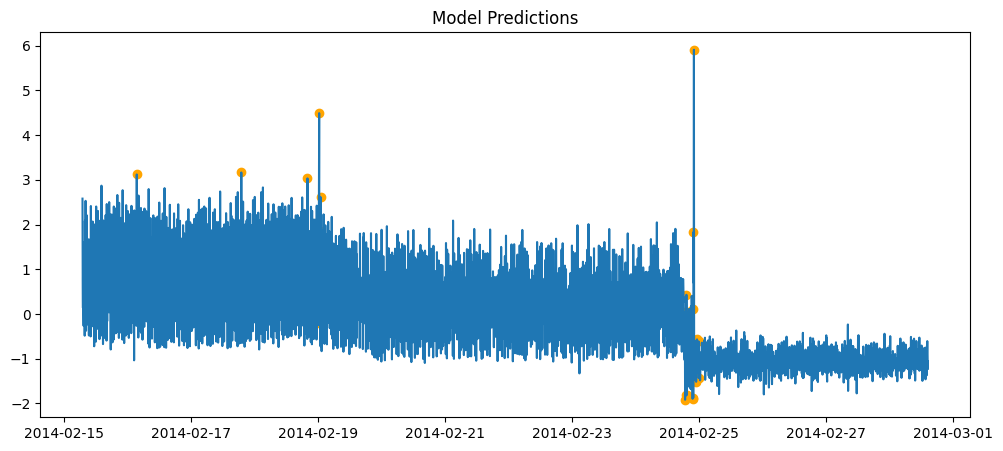

In [89]:
pred_anomalies = df[df['pred'] == 1]

plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['value'])
plt.scatter(pred_anomalies['timestamp'], pred_anomalies['value'], color='orange')
plt.title("Model Predictions")
plt.show()

In [90]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(df['anomaly'], df['pred']))
print("Recall:", recall_score(df['anomaly'], df['pred']))
print("F1 Score:", f1_score(df['anomaly'], df['pred']))

Precision: 0.05714285714285714
Recall: 1.0
F1 Score: 0.10810810810810811
